# Recurrent Neural Networks (RNN)

RNNs are designed to understand sequences, where the order of things matters. A Recurrent Neural Network (RNN) is a neural network designed to process things that unfold over time (or in a sequence in general)

Ordinary neural networks look at everything all at once. But time-structured data arrives step by step.

The code idea behind RNNs is:
> The network keeps a memory of the past and updates it as new input arrives.

This memory is what we call **the hidden state** in RNN jargon. 

- At time 1, the model sees something → updates its memory
- At time 2, it sees something new → updates the same memory
- At time 3, same thing

And so on

The network does not restart at each step. That’s what makes it recurrent.

Think of it like this: when you are hearing a sentence, you do not immediately forget the first word. To get a full understanding of the sentence you need to keep track of the words as you hear them and update your understanding of the meaning of the sentence as words come in. This is exactly what the RNN is doing. 

The hidden state is not the past itself — it’s a compressed summary of the past.

Now the math behind it: 

At each time step t:
$$h_t = f(x_t, h_{t-1})$$
- $x_t$: input at time t
- $h_t$: hidden state at time t 
	​

more precisely:
$$ h_t = \phi(W_hh_{t-1} + W_xx_t + b)$$

where $\phi$ is usally something like $tanh$ so we have: $ h_t = tanh(W_hh_{t-1} + W_xx_t + b)$

- $W_hh_{t-1}$: how much the past matters
- $W_xx_t$: how much the present matters
- b: bias
- $tanh$ is supposed to keep the values from blowing up.

It is called recurrent because at each stage, the output of the model is fed back to itself (present becomes past. Memory is updated based on what the model sees now)

It is important to note that:
An RNN is not:
- a storage of all past inputs
- a database
- a time-stamped memory

It is:
- a dynamic system that evolves over time

h = 0

for x in sequence:
    h = f(h, x)


## recurrence
The internal state of the model at time t - 1 influences the internal state at time t. The model keep updating its internal/hidden state over time

simply: new state=f(**old state**,new input)

## Hidden states: 
In RNNs, hidden state is the model’s internal memory at a particular moment in time.

An RNN has one internal memory space with a fixed size.  $h_t \in \mathbb{R}^{\text{hidden\_dim}}$ 

and so everything that influences the memory (or is used in updating the memory) will have to be in the same space with the same dimension. And because the update happens in the memory:
So we project:

- input → hidden space
- previous hidden → hidden space

First, a simple demonstration of recurrence and the equations we implement in a vanila RNN:

Here, we have a simple noisy, sinosuidal signal which we will try to predict using recurrence.


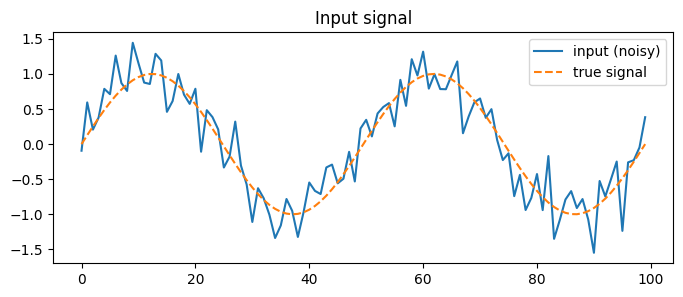

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# simulate a signal
T = 100                      # number of time steps
t = np.linspace(0, 4*np.pi, T)

x = np.sin(t)                # clean signal
x_noisy = x + 0.3 * np.random.randn(T)  # noisy input

plt.figure(figsize=(8, 3))
plt.plot(x_noisy, label="input (noisy)")
plt.plot(x, label="true signal", linestyle="--")
plt.legend()
plt.title("Input signal")
plt.show()


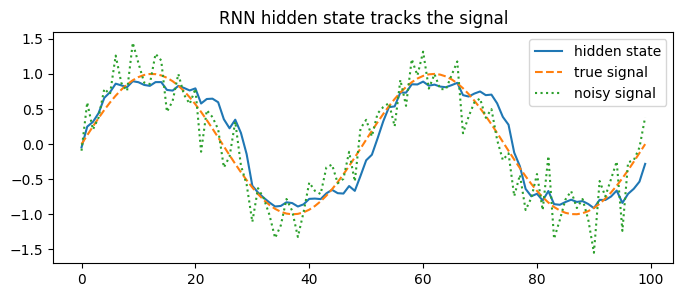

In [2]:
# Without any training, we simulate the function that the RNN is trying to implement
# RNN parameters (scalars!)
w_h = 0.9     # memory weight (past)
w_x = 0.5     # input weight (present)
b   = 0.0     # bias

def rnn_step(h_prev, x_t):
    return np.tanh(w_h * h_prev + w_x * x_t + b)


h = np.zeros(T)   # hidden state over time
h_prev = 0.0      # initial memory

for t in range(T):
    # This loop is recurrence
    # The same function is reused at every time step
    # The only thing that carries forward is h_prev
    h[t] = rnn_step(h_prev, x_noisy[t])
    h_prev = h[t]


# The hidden state is not the input.
# It’s a filtered, memory-based estimate of the input.
plt.figure(figsize=(8, 3))
plt.plot(h, label="hidden state")
plt.plot(x, linestyle="--", label="true signal")
plt.legend()
plt.plot(x_noisy, linestyle=":", label="noisy signal")
plt.legend()
plt.title("RNN hidden state tracks the signal")
plt.show()



- the hidden state is smoother than the actual noisy signal
- the hidden state is lagging with respect to the original noisy signal

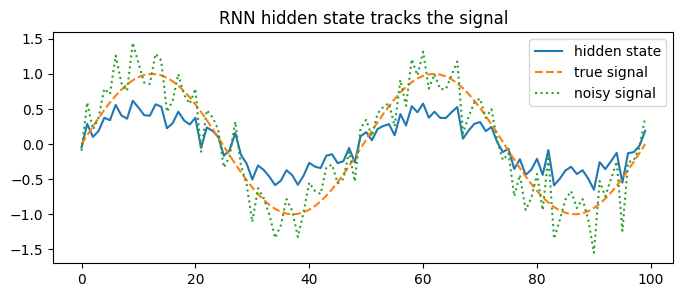

In [3]:
# now let's take a look at the role of the memory. 
# to look at the effect of memory, we set the w_h which is the weight of the previous states to 0
# Without any training, we simulate the function that the RNN is trying to implement
# RNN parameters (scalars!)
w_h = 0       # memory weight (past)
w_x = 0.5     # input weight (present)
b   = 0.0     # bias

def rnn_step(h_prev, x_t):
    return np.tanh(w_h * h_prev + w_x * x_t + b)


h = np.zeros(T)   # hidden state over time
h_prev = 0.0      # initial memory

for t in range(T):
    # This loop is recurrence
    # The same function is reused at every time step
    # The only thing that carries forward is h_prev
    h[t] = rnn_step(h_prev, x_noisy[t])
    h_prev = h[t]


# The hidden state is not the input.
# It’s a filtered, memory-based estimate of the input.
plt.figure(figsize=(8, 3))
plt.plot(h, label="hidden state")
plt.plot(x, linestyle="--", label="true signal")
plt.legend()
plt.plot(x_noisy, linestyle=":", label="noisy signal")
plt.legend()
plt.title("RNN hidden state tracks the signal")
plt.show()



- The hidden state now tracks the input instantaneously
- No temporal smoothing
- No memory

## The inductive biases

Definition of inductive bias: the assumptions a model makes before seeing any data. An inductive bias is the set of preferences a model has about what kinds of solutions are likely, built into its structure.

what are those built-in preferences here:

Let's take a look at the equation again:

$ h(t) = tanh(W_hh_{t-1} + W_xx(t) + b)$ 
- bias #1: time matters! What happened just before now is relevant to what happens now.
- bias #2: RNN does not store the full history
- bias #3: recent past matters more: The world has temporal continuity and decay. 
- bias #4: the dynamics are smooth (tanh)
- bias #5: Weight sharing: the same $W_h$ and $W_x$ and function (tanh in this example) are used for all the time steps

__The RNN didn’t learn to smooth the signal. It was built to smooth the signal.__

## coding an RNN

first we try to implement an RNN from scratch. THis would be a good excercise on building models as well. Pytorch, however, has RNNs as a class in torch.nn.Module. We will also try to build an RNN using pytorch. 

### nn.Module.RNN 
this is pytorch's class to create RNNs with these inputs:
- input_size: The number of expected features in the input x
- hidden_size: size of the internal memory (hidden state)
- num_layers = 1: number of layers. For >1 it will create stacked RNNs where the output of one RNN will be the input to the next
- nonlinearity='tanh': activation function applied in the recurrence
- bias=True: use bias weights?
- batch_first=False: then the input and output tensors are provided as (batch, seq, feature) instead of (seq, batch, feature). Note that this does not apply to hidden or cell states. See the Inputs/Outputs sections below for details. 
- dropout=0.0: regularization. If non-zero, introduces a Dropout layer on the outputs of each RNN layer except the last layer, with dropout probability equal to _dropout_.
- bidirectional=False, 
- device=None, dtype=None

In [ ]:
import torch
import torch.nn as nn

class myRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        # this is where you define the architecture
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        # we use the classic update rule here:
        # h(t) = tanh(W_h*h(t-1) + W_x*x(t) + b)
        # in this update rule, W_h and W_x are learnable weights
        # which by definition (as inductive biases) remain constant over time
        # you can think of W_h and W_x as learnable affine transformations
        # NOTE that the RNN has only one internal memory space
        # and so anything that influences the memory must be in that internal memory space
        # --- Learnable weights for the update rule ---
        self.W_x = nn.Linear(input_dim, hidden_dim, bias=True)
        # W_x corresponds to the term W_x x_t + b in the math.
        # It tells the model how the current input affects memory.

        self.W_h = nn.Linear(hidden_dim, hidden_dim, bias=False)
        # W_h corresponds to the term W_h h_{t-1}.
        # It tells the model how previous memory influences new memory.
        # We set bias=False here so we don't add the bias twice
        # (we already have bias in W_x).

        # it is also important to NOTE that W_x and W_h are defined as nn.Linear
        # which means they are not just a matrix
        # What is happening under the hood? for W_x
        # x_t @ W_x.weight.T + W_x.bias
        # and for self.W_h:
        # h_t @ W_h.weight.T (bias is set to False here)

        self.nonlinearity = torch.tanh
        # This is the tanh(·) in the RNN equation.
        # It keeps the hidden state bounded and introduces nonlinearity.

        # --- Learnable weights for producing outputs from hidden state ---
        self.W_y = nn.Linear(hidden_dim, output_dim, bias=True)
        # This is the readout: y_t = W_y h_t + b_y.
        # Important: the recurrence is in h_t, not y_t.
        # y_t is just what we want the model to report.

        # alternatively, we could have defined these using nn.Parameter
        # when you use nn.Linear, there are Parameters inside. In other words, 
        # nn.Linear is a container that will contain parameters
        # when we use nn.Parameter, we should also initialize them
        # on the other hand, using nn.Linear, the initialization is done automatically
        # self.W_x = nn.Parameter(torch.randn(self.input_dim, self.hidden_dim))
        # self.W_h = nn.Parameter(torch.randn(self.hidden_dim, self.hidden_dim))
        # self.b_h = nn.Parameter(torch.zeros(self.hidden_dim))

    def forward(self, x: torch.Tensor, h0: torch.Tensor | None = None):
        """
        x_seq:  Tensor of shape [batch, time, input_dim]
        h0: Optional initial hidden state of shape [batch, hidden_dim]

        Returns:
            y:  Tensor of shape [batch, time, output_dim]
            h:  Tensor of shape [batch, time, hidden_dim]  (all hidden states)
        """

        B, T, D = x.shape
        # B is batch size, T is time, D is input dim
        # NOTE that D must be equal to self.input_dim
        # you can raise an error here if that is not the case

        if D != self.input_dim:
            raise ValueError(f"Expected input_dim={self.input_dim}, got {D}")
        
        # --- Initialize hidden state (memory) ---
        if h0 is None:
            h_t = torch.zeros(B, self.hidden_dim, device=x.device, dtype=x.dtype)
            # If we don't provide an initial memory, start with zeros.
            # Conceptually: "the model begins with no information."

        else:
            # If provided, we start from a chosen initial memory state.
            h_t = h0

        h_all = []
        y_all = []
        # We'll store the hidden state and output at every time step
        # so we can visualize them and/or compute losses across time.

        # now the rollout begins
        # the recurrence happens in this loop (look we are rolling out)
        for t in range(T):
            # first get the x at time t
            x_t = x[:, t, :]
            # x_t is the input at time t for all sequences in the batch.
            # Shape: [B, input_dim]

            # now the update rule
            # NOTE this is our update rule: h(t) = tanh(W_h*h(t-1) + W_x*x(t)+b)
            # NOTE that self.W_x(x_t) is equivalent to writing:
            # W_x@x_t + b
            # Whenever you see layer(x), read it as: multiply by a matrix, add a bias.
            h_t = self.nonlinearity(self.W_h(h_t) + self.W_x(x_t))
            # This line directly matches:
            #   h_t = tanh(W_x x_t + W_h h_{t-1} + b)
            #
            # Key conceptual points:
            # 1) MEMORY: h_t depends on previous h_t (which is h_{t-1})
            # 2) RECURRENCE: we feed the hidden state forward in time
            # 3) WEIGHT SHARING: self.W_x and self.W_h are the SAME objects
            #    used for every t (same parameters reused at every step)

            # append it to h_all to keep track of it
            h_all.append(h_t)

            # now the output
            y_t = self.W_y(h_t)
            # Output readout. This does NOT feed back by default.
            # The "recurrent" part is h_t -> next h_t.

            # append it to y_all
            y_all.append(y_t)

        # Stack lists into tensors:
        h = torch.stack(h_all, dim=1)  # [B, T, hidden_dim]
        y = torch.stack(y_all, dim=1)  # [B, T, output_dim]
        return y, h


y: torch.Size([4, 10, 1])
h: torch.Size([4, 10, 8])


In [34]:
class VanilaRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        # the __init__ determines the architecture
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        # here's a list of inputs that nn.RNN takes:
        # (input_size, hidden_size, 
        # num_layers=1, nonlinearity='tanh', 
        # bias=True, batch_first=False, 
        # dropout=0.0, bidirectional=False, 
        # device=None, dtype=None)
        self.rnn = nn.RNN(input_size=self.input_dim, 
                          hidden_size=self.hidden_dim, 
                          num_layers=1, 
                          nonlinearity='tanh', 
                          bias=True, 
                          batch_first=True, 
                          dropout=0.0, 
                          bidirectional=False)
        
        # and the final layer:
        # NOTE that this is a task-dependent layer and it doesn't come with nn.RNN
        self.fc = nn.Linear(hidden_dim, output_dim, bias=True)
        

    def forward(self, x):
        out, h = self.rnn(x)
        # print(out.shape, h.shape)
        # y = self.fc(out[:, -1, :]).squeeze(-1)   # last timestep → scalar
        y = self.fc(out)   # last timestep → scalar
        return y, h

Now let's test the two without training:

In [35]:
# a simple example. SIMULATE SOME DATA
# the goal is to predict the next value of a 1D signal
# we have a noisy sinosuidal X and Y contains the next state
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)

# Create sine wave data
T = 100
t = np.linspace(0, 8*np.pi, T)
signal = np.sin(t)

# Add noise
signal_noisy = signal + 0.2 * np.random.randn(T)

# Convert to tensors
x = torch.tensor(signal_noisy[:-1], dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
y = torch.tensor(signal_noisy[1:], dtype=torch.float32).unsqueeze(0).unsqueeze(-1)


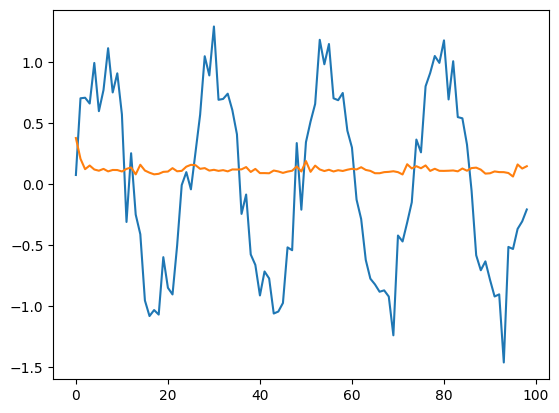

In [36]:
# now create an instance of myRNN. 
# you need input_dim, hidden_dim, and output_dim
x.shape
y.shape
input_dim = 1
output_dim = 1

RNN_new = myRNN(hidden_dim=32, input_dim=1, output_dim=1)
y_pred, h = RNN_new.forward(x)
# convert y_pred to numpy 

plt.plot(y[0, :, 0])
plt.plot(y_pred.detach().numpy()[0,:, 0])

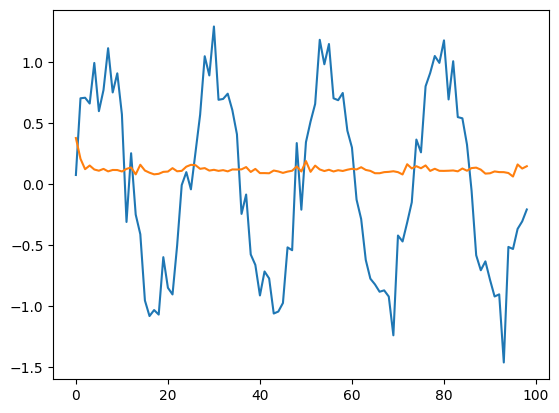

In [37]:
RNN_torch = VanilaRNN(input_dim=1, hidden_dim=32, output_dim=1)
y_pred2, h2 = RNN_torch.forward(x)

plt.plot(y[0, :, 0])
plt.plot(y_pred.detach().numpy()[0,:, 0])

Not so good! Now we train the model! For training, like before, we need to define a loss function and an optimizer

Epoch 0, Loss1: 0.5793
Epoch 0, Loss2: 0.6448
Epoch 50, Loss1: 0.0514
Epoch 50, Loss2: 0.0477
Epoch 100, Loss1: 0.0346
Epoch 100, Loss2: 0.0520
Epoch 150, Loss1: 0.0283
Epoch 150, Loss2: 0.0385
Epoch 200, Loss1: 0.0248
Epoch 200, Loss2: 0.0280
Epoch 250, Loss1: 0.0233
Epoch 250, Loss2: 0.0176
Epoch 300, Loss1: 0.0216
Epoch 300, Loss2: 0.0168
Epoch 350, Loss1: 0.0195
Epoch 350, Loss2: 0.0180
Epoch 400, Loss1: 0.0166
Epoch 400, Loss2: 0.0132
Epoch 450, Loss1: 0.0109
Epoch 450, Loss2: 0.0120
Epoch 500, Loss1: 0.0072
Epoch 500, Loss2: 0.0085
Epoch 550, Loss1: 0.0052
Epoch 550, Loss2: 0.0074
Epoch 600, Loss1: 0.0038
Epoch 600, Loss2: 0.0054
Epoch 650, Loss1: 0.0029
Epoch 650, Loss2: 0.0034
Epoch 700, Loss1: 0.0010
Epoch 700, Loss2: 0.0021
Epoch 750, Loss1: 0.0005
Epoch 750, Loss2: 0.0017
Epoch 800, Loss1: 0.0003
Epoch 800, Loss2: 0.0055
Epoch 850, Loss1: 0.0002
Epoch 850, Loss2: 0.0007
Epoch 900, Loss1: 0.0003
Epoch 900, Loss2: 0.0005
Epoch 950, Loss1: 0.0004
Epoch 950, Loss2: 0.0004


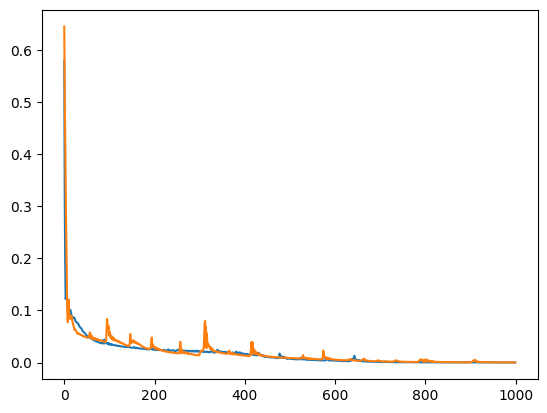

In [39]:
import torch.optim as optim
model1 = myRNN(input_dim=1, hidden_dim=32, output_dim=1)
model2 = VanilaRNN(input_dim=1, hidden_dim=32, output_dim=1)
# we will use an adam optimizer
optimizer1 = optim.Adam(model1.parameters(), lr=0.01)
optimizer2 = optim.Adam(model2.parameters(), lr=0.01)

# now the loss function: we use a simple MSE
loss_fn1 = nn.MSELoss()
loss_fn2 = nn.MSELoss()

loss_all1 = []
loss_all2 = []
for epoch in range(1000): 
    # first clear out all the grad values
    # clear out gradients
    # if you don't do this, the grad is gonna accumulate(The new gradients are added on top of the old ones.)
    # Gradients grow larger and larger.
    # general rule: when you are training, the first thing you do is always to clear out the gradients
    # run the model and get the predictions
    # calculate the current loss
    # backprop (backward)
    # update the parameters
    # 
    optimizer1.zero_grad() # comment out to see the effect
    optimizer2.zero_grad() # comment out to see the effect
    # run the model once
    # you can alternatively do: y_pred, h = model(x)
    y_pred, h = model1(x)
    y_pred2, h2 = model2(x)

    # calculate the loss
    current_loss1 = loss_fn1(y_pred, y)
    current_loss2 = loss_fn2(y_pred2, y)

    # run backprop
    current_loss1.backward()
    current_loss2.backward()

    loss_all1.append(current_loss1.item())
    loss_all2.append(current_loss2.item())
    # update the parameters
    optimizer1.step()
    optimizer2.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss1: {current_loss1.item():.4f}")
        print(f"Epoch {epoch}, Loss2: {current_loss2.item():.4f}")

plt.plot(loss_all1)
plt.plot(loss_all2)



You can see that both the loss for both models decreases and reaches 0. Now let's take a look at the predictions

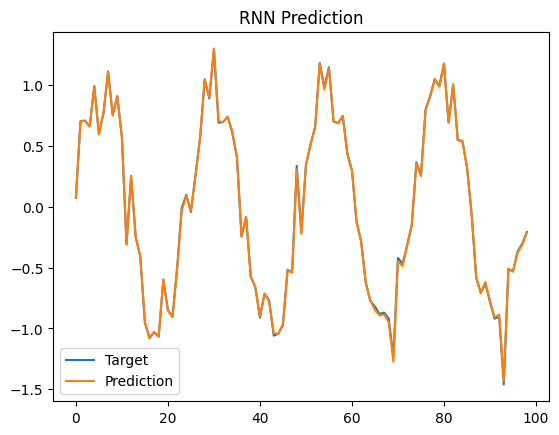

In [40]:
with torch.no_grad():
    pred1, h1 = model1(x)
    pred1 = pred1.detach().numpy()

plt.plot(signal_noisy[1:], label="Target")
plt.plot(pred1[0, :, 0], label="Prediction")
plt.legend()
plt.title("RNN Prediction")
plt.show()


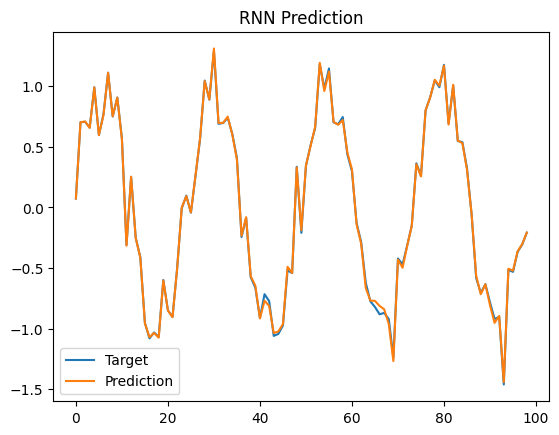

In [41]:
with torch.no_grad():
    pred2, h2 = model2(x)
    pred2 = pred2.detach().numpy()

plt.plot(signal_noisy[1:], label="Target")
plt.plot(pred2[0, :, 0], label="Prediction")
plt.legend()
plt.title("RNN Prediction")
plt.show()


This was just an example to show how we can use RNNs to predict a timeseries. Another example would be a classification. We will be using the VanilaRNN which we built using Pytorch. 

## Vanishing gradients

The goal here is to see one of the main problems of RNNs: _vanishing gradients_. As the name implies, it is a problem that arises when the gradients become so small. 

We derived that the gradient of the loss with respect to an earlier hidden state
is given by:

$$
\frac{\partial L}{\partial h_t}
=
J_{t+1}^\top
J_{t+2}^\top
\cdots
J_T^\top
\, g_T
$$

where

$$
g_T = \frac{\partial L}{\partial h_T}
$$

and each Jacobian term is:

$$
J_k
=
\frac{\partial h_k}{\partial h_{k-1}}
=
\mathrm{diag}(1 - h_k^2)\, W_h
$$

Thus, the gradient at time step $t$ is a product of many matrices:

$$
\frac{\partial L}{\partial h_t}
=
\left(
\prod_{k=t+1}^{T} J_k^\top
\right)
g_T
$$

If, on average,

$$
\| J_k \| \approx \alpha < 1
$$


then

$$
\left\|
\frac{\partial L}{\partial h_t}
\right\|
\approx
\alpha^{(T-t)}
\,
\| g_T \|
$$

which decays exponentially in the distance $(T - t)$.

This exponential decay of gradient magnitude as we move backward in time is known as the **vanishing gradient problem**.


So we need a way for gradients to flow backward without being multiplied repeatedly by shrinking terms.

In other words:

We need a path where gradients are preserved:

But before we offer the solution, here's a demonstration of the problem


_________________________________________________________
Alternative explanation:

But why is that?
For a vanilla RNN, the final output depends on the final hidden state $h_T$. And $h_T$ depends on $h_{T-1}$, which depends on $h_{T-2}$, … all the way back to early time steps where the PIN was presented.

So when you train, the **learning signal (the gradient)** has to travel backward through many recurrent steps.

That backward flow looks like repeated multiplication of matrices (and elementwise derivatives). Repeated multiplication is exactly where things can:

- shrink exponentially → **vanishing gradient**
- grow exponentially → **exploding gradient**

In a long-memory PIN task, the typical failure is **vanishing gradients**: the learning signal for early steps becomes tiny, so the model can’t learn a good “store and keep” strategy as the gap grows.

Mathematically:

RNN update:
$$h_t = tanh(W_hh_{t-1} + W_xx_t + b)$$
Assume the loss L depends on $h_T$ (because we decode the PIN from the final hidden state). And to update parameters that affect early time steps, we need gradients like $\frac{∂𝐿}{∂{h_t}}$ which by the chain rule:

$$\frac{∂𝐿}{∂{h_t}} = \frac{∂𝐿}{∂{h_T}}.\frac{∂{h_T}}{∂{h_{T-1}}}.\frac{∂h_{T-1}}{∂{h_{T-2}}}...\frac{∂h_{t+1}}{∂{h_{t}}}$$

That product is the whole story.
Each factor is a jacobian:

$$\frac{∂{h_k}}{∂{h_{k-1}}} = diag(1-tanh^2(a_k))W_h$$

and $|1-tanh^2(.)|≤1$

So when you multiply many of these together, the norm tends to shrink quickly unless conditions are just right. And the further back you need to go, the worse the problem gets. **That shrinkage is the vanishing gradient.**

Think of backprop through time like passing a message backward through a long chain of people. If each person passes along only 90% of the message, then after 100 people the message is basically gone. If each passes 110%, it blows up. **An RNN with long sequences is asking gradients to survive a long chain.**

In [57]:
def gradient_autopsy(T=50, hidden_size=32, input_size=1):
    """
    Forward pass of length T, then backprop.
    Returns gradient norms at each timestep.
    """
    # RNNCell, unlike nn.RNN, only runs one time step, not the whole sequence
    rnn_cell = nn.RNNCell(input_size, hidden_size, nonlinearity='tanh')

    # Random input sequence — we don't care about the task here,
    # just the gradient flow.
    x = torch.randn(T, input_size)
    h = torch.zeros(hidden_size, requires_grad=False)

    # Store hidden states so we can call .retain_grad() on each
    hiddens = []
    for t in range(T):
        h = rnn_cell(x[t].unsqueeze(0), h.unsqueeze(0)).squeeze(0)
        h.retain_grad()          # ← normally intermediate grads are discarded
        hiddens.append(h)

    # Scalar loss at the very last timestep only
    loss = hiddens[-1].sum()
    loss.backward()

    # Collect ‖∂loss/∂h_t‖ for each t
    grad_norms = [h.grad.norm().item() for h in hiddens]
    return grad_norms



def make_batch(batch_size, seq_len, num_classes=8):
    """
    Returns (inputs, targets).
    inputs:  (batch, seq_len, 1) — one-hot class encoded as float in [0,1]
    targets: (batch,)            — the class shown at t=0
    """
    # generate random labels/classes
    labels = torch.randint(0, num_classes, (batch_size,))
    # encode label as a unique value in (0,1) so it's a regression target
    signal = (labels.float() + 1) / (num_classes + 1)   # avoids 0 and 1

    inputs = torch.zeros(batch_size, seq_len, 1)
    inputs[:, 0, 0] = signal          # only the first timestep carries info
    targets = signal                   # predict it at the last timestep
    return inputs, targets

def train(model, seq_len, epochs=300, batch_size=128, lr=1e-3):
    # define an optimizer first. Here we will use adam
    opt = optim.Adam(model.parameters(), lr=lr)
    # define a loss function: here simple MSE
    loss_fn = nn.MSELoss()
    history = []
    for epoch in range(epochs):
        # create a batch of simulated x and y
        x, y = make_batch(batch_size, seq_len)
        # get the predictions
        pred = model(x)
        # calculate loss
        loss = loss_fn(pred, y)
        # clear out previous values of the gradients
        # otherwirse current values will be added to the previous one
        opt.zero_grad()
        # backprop
        loss.backward()
        # need to do step in order to update the parameters
        opt.step()
        # record the current loss
        history.append(loss.item())
    return history


class VanillaRNN(nn.Module):
    def __init__(self, hidden_size=64):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size,
                          batch_first=True, nonlinearity='tanh')
        self.fc  = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]).squeeze(-1)   # last timestep → scalar

In [53]:
print("Running gradient autopsy …")
T = 60
grad_norms = gradient_autopsy(T=T)

# ─── also vary sequence length to show the trend ────────────────────────────
lengths = [10, 20, 40, 80]
grad_at_first_step = []
for length in lengths:
    # get the norm of the gradient
    norms = gradient_autopsy(T=length)
    # only get the gradient at t = 0 (this will be the oldest!)
    grad_at_first_step.append(norms[0])   # gradient at t=0 (the oldest step)



Running gradient autopsy …


Let's run a simple long-range memory task. The task is simple:

The network must remember what it saw at t=0 across T-1 filler steps.

Short sequences → easy. Long sequences → vanilla RNN forgets.

In [54]:
# ════════════════════════════════════════════════════════════════════════════
# LONG-RANGE MEMORY TASK
# ════════════════════════════════════════════════════════════════════════════
#
# Task: "Echo the first token after a long silence"
#
# Input:  [signal, 0, 0, 0, …, 0]    (T tokens total)
# Target: predict the signal value at the LAST step
#
# The network must remember what it saw at t=0 across T-1 filler steps.
# Short sequences → easy. Long sequences → vanilla RNN forgets.
# ─────────────────────────────────────────────────────────────────────────────

In [55]:
seq_short, seq_long = 10, 50
results = {}

for label, seq_len in [("short (T=10)", seq_short), ("long  (T=50)", seq_long)]:
    rnn_model  = VanillaRNN(hidden_size=64)
    results[label] = {
        "rnn":  train(rnn_model,  seq_len),
    }
    print(f"  {label} done")

  short (T=10) done
  long  (T=50) done


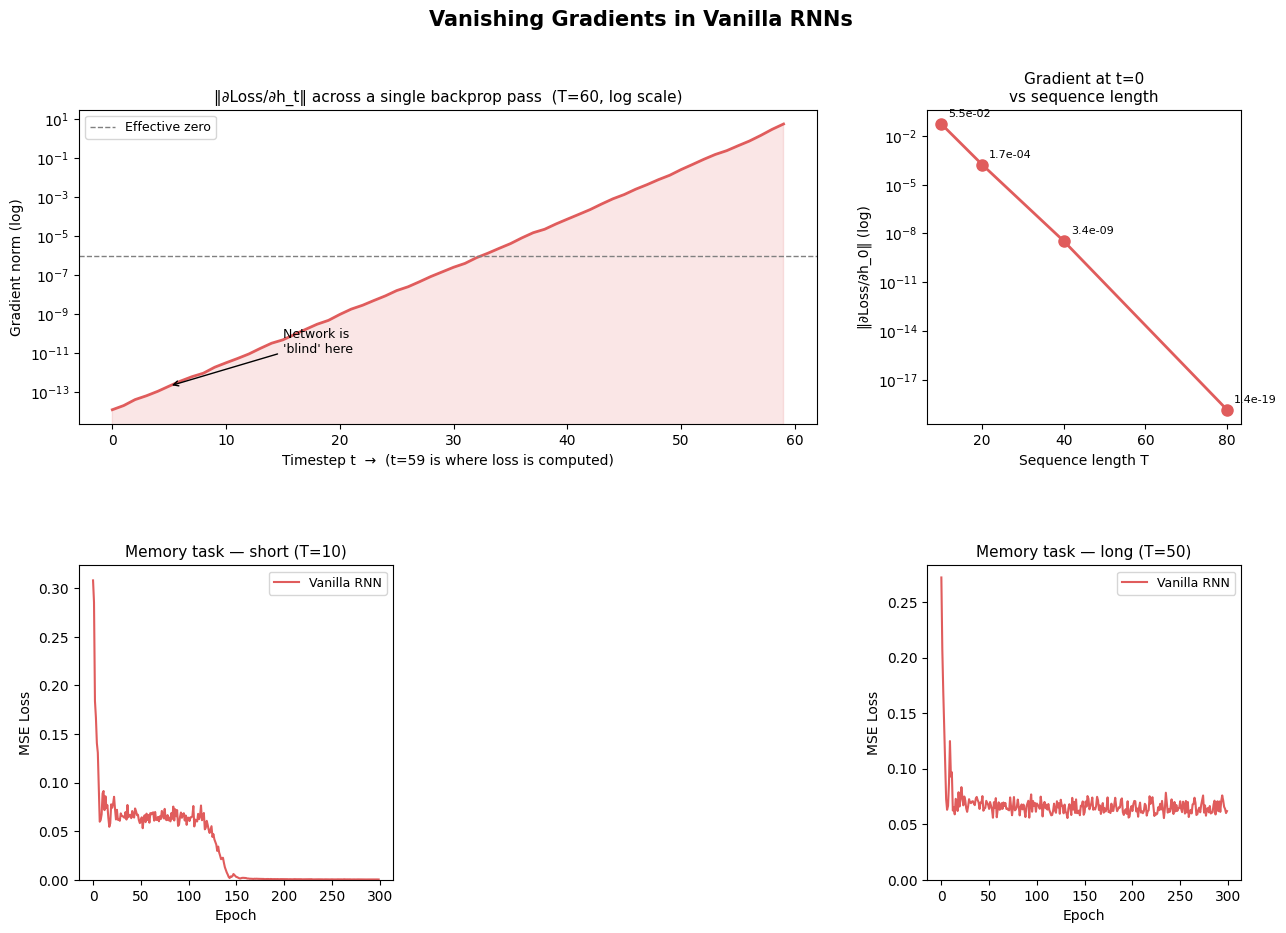

In [56]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(15, 10))
fig.suptitle("Vanishing Gradients in Vanilla RNNs", fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

COLORS = {"rnn": "#e05c5c"}
# ── Plot 1: gradient norms along time (the autopsy) ──────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
timesteps = list(range(T))
ax1.semilogy(timesteps, grad_norms, color='#e05c5c', lw=2)
ax1.axhline(1e-6, color='gray', ls='--', lw=1, label='Effective zero')
ax1.fill_between(timesteps, grad_norms, alpha=0.15, color='#e05c5c')
ax1.set_title("‖∂Loss/∂h_t‖ across a single backprop pass  (T=60, log scale)",
              fontsize=11)
ax1.set_xlabel("Timestep t  →  (t=59 is where loss is computed)")
ax1.set_ylabel("Gradient norm (log)")
ax1.legend(fontsize=9)
ax1.annotate("Network is\n'blind' here",
             xy=(5, grad_norms[5]), xytext=(15, grad_norms[5]*50),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

# ── Plot 2: gradient at t=0 vs sequence length ────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.semilogy(lengths, grad_at_first_step, 'o-', color='#e05c5c', lw=2, ms=8)
ax2.set_title("Gradient at t=0\nvs sequence length", fontsize=11)
ax2.set_xlabel("Sequence length T")
ax2.set_ylabel("‖∂Loss/∂h_0‖ (log)")
for x, y in zip(lengths, grad_at_first_step):
    ax2.annotate(f"{y:.1e}", (x, y), textcoords="offset points",
                 xytext=(5, 5), fontsize=8)

# ── Plots 3 & 4: training loss curves ────────────────────────────────────────
for col, (label, res) in enumerate(results.items()):
    ax = fig.add_subplot(gs[1, col + (1 if col == 1 else 0)])
    ax.plot(res["rnn"],  label="Vanilla RNN", color=COLORS["rnn"],  lw=1.5)
    ax.set_title(f"Memory task — {label}", fontsize=11)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)

# Re-lay the 3rd plot cleanly (it shares a cell with plot 2 area workaround)
ax_long = fig.add_subplot(gs[1, 2])
res = results["long  (T=50)"]
ax_long.plot(res["rnn"],  label="Vanilla RNN", color=COLORS["rnn"],  lw=1.5)
ax_long.set_title("Memory task — long (T=50)", fontsize=11)
ax_long.set_xlabel("Epoch")
ax_long.set_ylabel("MSE Loss")
ax_long.legend(fontsize=9)
ax_long.set_ylim(bottom=0)

# Fix: overwrite the duplicate axis created in the loop
fig.axes[3].remove()   # remove the wrongly placed 4th axis from the loop

In the first plot, you see the norm of the gradient at each time step. When the norm is small, as it is the case in early time step, the contribution of that time step is very small. You can also see that as the length of the sequence increases, the magnitude of the gradient at t = 0 decreases exponentially (y-axis is in log space). You can also see that the MSE loss for a short term memory task reaches 0 at around 150 epochs, whereas for a long term memory task it never reaches 0. 


To handle this problem, we use lstms! 